In [1]:
from ultralytics import YOLO
from PIL import Image
from IPython.display import display

In [3]:
model = YOLO('yolov9t.pt') 

yaml_path = 'C:/Users/Benja/Desktop/Machine Learning/White_Cane_YOLO_Ready/dataset.yaml'

print("Initializing training sequence...")

# device=0 attempts to force the script to use your dedicated GPU
results = model.train(
    data=yaml_path, 
    epochs=50,       # 50 passes through the dataset is a solid initial test
    imgsz=640,       # Standard YOLO resolution
    batch=16,        # How many images to load into VRAM at once (lower this to 8 if you get an Out of Memory error)
    device=0,        
    workers=0
)

Initializing training sequence...
New https://pypi.org/project/ultralytics/8.4.35 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.31  Python-3.12.0 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:/Users/Benja/Desktop/Machine Learning/White_Cane_YOLO_Ready/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=t


image 1/1 C:\Users\Benja\Desktop\Proyecto de titulo github\Modelo-deteccion-de-objetos-Proyecto-de-titulo\Notebooks\palo_ciego2.jpg: 448x640 1 White_Cane, 32.9ms
Speed: 1.2ms preprocess, 32.9ms inference, 5.5ms postprocess per image at shape (1, 3, 448, 640)
Results saved to C:\Users\Benja\Desktop\Proyecto de titulo github\Modelo-deteccion-de-objetos-Proyecto-de-titulo\Notebooks\runs\detect\predict10


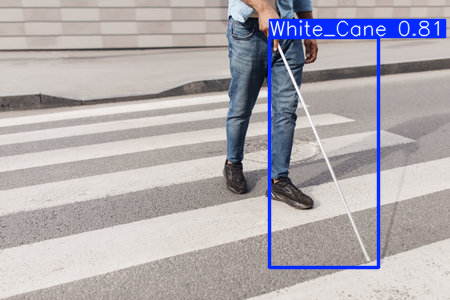

In [2]:
# Actualizar con el camino al modelo entrenado
model_path = r"C:\Users\Benja\Desktop\Proyecto de titulo github\Machine Learning\Modelos Entrenados\yolo9n_bastones_v1.pt"
model = YOLO(model_path)


# Actualizar con el camino a la imagen
image_path = r"palo_ciego2.jpg"

# conf=0.5 significa que solo dibuja la caja si esta almenos un 50% seguro de que es el objeto
# save=True si quieres que dibuje las cajas y guarde la imagen como una copia nueva
results = model.predict(source=image_path, conf=0.5, save=True)
# Extrae el primer resultado (como solo se paso 1 imagen)
result = results[0]

# .plot() dibuja los cuadros delimitadores y los devuelve como una matriz
img_array = result.plot()

# Usamos [..., ::-1] para convertirlo rápidamente a RGB estándar para que los colores no se inviertan
img_array_rgb = img_array[..., ::-1]

# Muestra la imagen
display(Image.fromarray(img_array_rgb))